<a href="https://colab.research.google.com/github/shakhaoathpappu-jpg/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shakhaoathpappu-jpg/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Which published pages are likely to need a content refresh — based on staleness (time since last update) and how far their CTR falls short of what similarly-ranked pages typically get?

Decision this supports: Given a limited content-ops budget, which pages should be prioritized for refresh this month, and why (so the reasoning is auditable, not a black box).

# 2. Data

Which release, which tables, date windows, what you excluded and why. Public-safe.

Release: FlyRank ML Internship warehouse (Hugging Face, FlyRank/internship-warehouse).
Tables used: fact_content_daily_performance (daily grain, aggregated to page-month) and dim_content (content metadata: created/updated dates, publish status).
Date window: 2025-01 through 2026-06 (18 months). 2025-01–2026-05 used for training/validation; 2026-06 is the dataset's sealed final month, held out and used only once for final honest evaluation.
Excluded: client names, URLs, and raw search queries (all identifiers stay hashed); unpublished or deleted content; any column derived from a future month relative to a given decision point.

In [1]:
import gc
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "FlyRank/internship-warehouse"

ALL_TRAIN_VAL_MONTHS = [f"2025-{m:02d}" for m in range(1, 13)] + [f"2026-{m:02d}" for m in range(1, 6)]
SEALED_TEST_MONTH = "2026-06"
ALL_MONTHS = ALL_TRAIN_VAL_MONTHS + [SEALED_TEST_MONTH]

dim_content_path = hf_hub_download(repo_id=REPO_ID, repo_type="dataset", filename="dim_content.parquet", token=HF_TOKEN)
dim_content = pd.read_parquet(dim_content_path)
dim_content["content_created_date"] = pd.to_datetime(dim_content["content_created_date"], errors="coerce")
dim_content["content_updated_date"] = pd.to_datetime(dim_content["content_updated_date"], errors="coerce")

def aggregate_month(df, month):
    m = (
        df.groupby(["client_hash_id", "content_hash_id"], as_index=False)
        .agg(
            gsc_clicks=("gsc_clicks", "sum"),
            gsc_impressions=("gsc_impressions", "sum"),
            gsc_sum_position=("gsc_sum_position", "sum"),
            days_with_gsc=("gsc_data_available", "sum"),
        )
    )
    m["month"] = month
    impressions_f = m["gsc_impressions"].astype(float).replace(0, np.nan)
    m["ctr"] = m["gsc_clicks"].astype(float) / impressions_f
    m["avg_position"] = m["gsc_sum_position"].astype(float) / impressions_f
    return m[m["days_with_gsc"] > 0].copy()

def load_and_aggregate(month):
    path = hf_hub_download(
        repo_id=REPO_ID, repo_type="dataset",
        filename=f"fact_content_daily_performance/month={month}/data_0.parquet",
        token=HF_TOKEN
    )
    raw = pd.read_parquet(path)
    agg = aggregate_month(raw, month)
    del raw
    gc.collect()
    return agg

panel_parts = []
for m in ALL_MONTHS:
    print("Loading + aggregating", m, "...")
    part = load_and_aggregate(m)
    panel_parts.append(part)
    print(f"  -> {len(part)} page-month rows")

panel_df = pd.concat(panel_parts, ignore_index=True)
del panel_parts
gc.collect()

print("\n=== FULL PANEL ===")
print("Shape:", panel_df.shape)
print(panel_df["month"].value_counts().sort_index())
print("\nUnique pages overall:", panel_df["content_hash_id"].nunique())
print("Unique clients overall:", panel_df["client_hash_id"].nunique())

Loading + aggregating 2025-01 ...
  -> 476 page-month rows
Loading + aggregating 2025-02 ...
  -> 5903 page-month rows
Loading + aggregating 2025-03 ...
  -> 10374 page-month rows
Loading + aggregating 2025-04 ...
  -> 13046 page-month rows
Loading + aggregating 2025-05 ...
  -> 14887 page-month rows
Loading + aggregating 2025-06 ...
  -> 16399 page-month rows
Loading + aggregating 2025-07 ...
  -> 27945 page-month rows
Loading + aggregating 2025-08 ...
  -> 37204 page-month rows
Loading + aggregating 2025-09 ...
  -> 53127 page-month rows
Loading + aggregating 2025-10 ...
  -> 64906 page-month rows
Loading + aggregating 2025-11 ...
  -> 99403 page-month rows
Loading + aggregating 2025-12 ...
  -> 109639 page-month rows
Loading + aggregating 2026-01 ...
  -> 121544 page-month rows
Loading + aggregating 2026-02 ...
  -> 153559 page-month rows
Loading + aggregating 2026-03 ...
  -> 176738 page-month rows
Loading + aggregating 2026-04 ...
  -> 194760 page-month rows
Loading + aggregating 

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: a page "needs refresh" if its clicks in the month after the decision point are lower than in the decision month itself. All features are computed strictly from the decision month or earlier.
Features: gsc_clicks, gsc_impressions, ctr, avg_position, staleness_score (days since last content update, capped at 180 days), ctr_gap (how far actual CTR falls below the median CTR for that position bucket).
Baseline: the ML-07 rule-based score — 0.5*staleness_score + 0.5*ctr_gap — with no training required.
Validation design: time-aware split, no random shuffling — train on the earliest decision months, validate on the middle months, and evaluate once, honestly, on the sealed final decision month (2026-05 → outcome 2026-06).
Leakage checks: decision-month ranges for train/val/test are strictly non-overlapping in time; the label itself (future_clicks) is never used as a feature.

In [3]:
MONTH_ORDER = ALL_MONTHS  # already chronological: 2025-01 ... 2026-06
month_to_idx = {m: i for i, m in enumerate(MONTH_ORDER)}

def next_month(m):
    idx = month_to_idx[m]
    return MONTH_ORDER[idx + 1] if idx + 1 < len(MONTH_ORDER) else None

def position_bucket(p):
    if pd.isna(p): return "unknown"
    if p <= 3: return "1-3"
    if p <= 10: return "4-10"
    if p <= 20: return "11-20"
    return "21+"

def decision_date(month_str):
    return pd.Period(month_str, freq="M").end_time.normalize()

def build_pairs(decision_months):
    frames = []
    for dm in decision_months:
        om = next_month(dm)
        cur = panel_df[panel_df["month"] == dm].copy()
        nxt = panel_df[panel_df["month"] == om][["client_hash_id", "content_hash_id", "gsc_clicks"]] \
              .rename(columns={"gsc_clicks": "future_clicks"})
        merged = cur.merge(nxt, on=["client_hash_id", "content_hash_id"], how="inner")
        merged["decision_month"] = dm
        merged["outcome_month"] = om
        frames.append(merged)
    return pd.concat(frames, ignore_index=True)

def add_features(df):
    df = df.merge(
        dim_content[["client_hash_id", "content_hash_id", "content_created_date", "content_updated_date",
                      "is_published", "is_deleted", "content_type"]],
        on=["client_hash_id", "content_hash_id"], how="left"
    )
    df["decision_date"] = df["decision_month"].apply(decision_date)
    df = df[(df["is_published"] == True) & (df["is_deleted"] == False)]
    df = df[df["content_created_date"].isna() | (df["content_created_date"] <= df["decision_date"])]

    df["days_since_update"] = (df["decision_date"] - df["content_updated_date"]).dt.days
    df.loc[df["days_since_update"] < 0, "days_since_update"] = np.nan

    df["position_bucket"] = df["avg_position"].apply(position_bucket)
    bucket_median_ctr = df.groupby("position_bucket")["ctr"].transform("median")
    df["ctr_gap"] = (1 - (df["ctr"] / bucket_median_ctr)).clip(lower=0, upper=1).fillna(0)

    STALE_CAP_DAYS = 180
    df["staleness_score"] = (df["days_since_update"].clip(upper=STALE_CAP_DAYS) / STALE_CAP_DAYS).fillna(0)
    df["needs_refresh"] = (df["future_clicks"] < df["gsc_clicks"]).astype(int)
    return df

# Non-overlapping, chronologically ordered splits
TRAIN_DECISION_MONTHS = MONTH_ORDER[0:9]    # 2025-01 .. 2025-09
VAL_DECISION_MONTHS   = MONTH_ORDER[9:16]   # 2025-10 .. 2026-04
TEST_DECISION_MONTH   = MONTH_ORDER[16]     # 2026-05  (outcome = sealed 2026-06)

train_df = add_features(build_pairs(TRAIN_DECISION_MONTHS))
val_df   = add_features(build_pairs(VAL_DECISION_MONTHS))
test_df  = add_features(build_pairs([TEST_DECISION_MONTH]))

print("train:", train_df.shape, "positive rate:", round(train_df["needs_refresh"].mean(), 4))
print("val:  ", val_df.shape,   "positive rate:", round(val_df["needs_refresh"].mean(), 4))
print("test: ", test_df.shape,  "positive rate:", round(test_df["needs_refresh"].mean(), 4))

# Leakage / time-ordering check
print("\nTrain decision months:", sorted(train_df['decision_month'].unique()))
print("Val decision months:  ", sorted(val_df['decision_month'].unique()))
print("Test decision month:  ", sorted(test_df['decision_month'].unique()))
assert max(train_df['decision_month']) < min(val_df['decision_month']), "Train/val time overlap!"
assert max(val_df['decision_month']) < min(test_df['decision_month']), "Val/test time overlap!"
print("\nNo time overlap between splits — confirmed.")


train: (165628, 23) positive rate: 0.1591
val:   (824031, 23) positive rate: 0.2075
test:  (180723, 23) positive rate: 0.2642

Train decision months: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09']
Val decision months:   ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test decision month:   ['2026-05']

No time overlap between splits — confirmed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The honest table below compares the rule-based baseline to a trained model on the same, never-touched-until-now sealed test split.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

FEATURE_COLS = ["gsc_clicks", "gsc_impressions", "ctr", "avg_position", "staleness_score", "ctr_gap"]

def prep_X(df):
    return df[FEATURE_COLS].fillna(0)

X_train, y_train = prep_X(train_df), train_df["needs_refresh"]
X_val, y_val = prep_X(val_df), val_df["needs_refresh"]
X_test, y_test = prep_X(test_df), test_df["needs_refresh"]

baseline_val_score = 0.5 * val_df["staleness_score"] + 0.5 * val_df["ctr_gap"]
baseline_test_score = 0.5 * test_df["staleness_score"] + 0.5 * test_df["ctr_gap"]
baseline_val_auc = roc_auc_score(y_val, baseline_val_score)
baseline_test_auc = roc_auc_score(y_test, baseline_test_score)

model = GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.05)
model.fit(X_train, y_train)

model_val_score = model.predict_proba(X_val)[:, 1]
model_test_score = model.predict_proba(X_test)[:, 1]
model_val_auc = roc_auc_score(y_val, model_val_score)
model_test_auc = roc_auc_score(y_test, model_test_score)

results_table = pd.DataFrame({
    "split": ["validation", "validation", "sealed_test", "sealed_test"],
    "approach": ["baseline (rule)", "model (GBM)", "baseline (rule)", "model (GBM)"],
    "auc": [baseline_val_auc, model_val_auc, baseline_test_auc, model_test_auc],
    "n": [len(y_val), len(y_val), len(y_test), len(y_test)],
    "positive_rate": [y_val.mean(), y_val.mean(), y_test.mean(), y_test.mean()],
})
print(results_table)

feature_importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nFeature importances:\n", feature_importance)

         split         approach       auc       n  positive_rate
0   validation  baseline (rule)  0.501271  824031       0.207465
1   validation      model (GBM)  0.909431  824031       0.207465
2  sealed_test  baseline (rule)  0.380566  180723       0.264239
3  sealed_test      model (GBM)  0.912937  180723       0.264239

Feature importances:
 ctr                0.889760
avg_position       0.079760
gsc_impressions    0.024106
gsc_clicks         0.006150
ctr_gap            0.000154
staleness_score    0.000069
dtype: float64


In [5]:
from sklearn.metrics import roc_auc_score

# Sanity check: is the model's AUC driven by a floor-effect artifact in the label
# (clicks can't go below 0, so zero-click pages can never "decline" by definition)?

for name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    zero_click_rate = (df_["gsc_clicks"] == 0).mean()
    print(f"{name}: {zero_click_rate:.1%} of rows have 0 clicks at the decision month")

MIN_CLICKS = 1
val_f1 = val_df[val_df["gsc_clicks"] >= MIN_CLICKS]
test_f1 = test_df[test_df["gsc_clicks"] >= MIN_CLICKS]

model_val_f1 = roc_auc_score(val_f1["needs_refresh"], model.predict_proba(prep_X(val_f1))[:, 1])
model_test_f1 = roc_auc_score(test_f1["needs_refresh"], model.predict_proba(prep_X(test_f1))[:, 1])
base_val_f1 = roc_auc_score(val_f1["needs_refresh"], 0.5*val_f1["staleness_score"] + 0.5*val_f1["ctr_gap"])
base_test_f1 = roc_auc_score(test_f1["needs_refresh"], 0.5*test_f1["staleness_score"] + 0.5*test_f1["ctr_gap"])

print(f"\n=== Requiring gsc_clicks >= {MIN_CLICKS} at decision time ===")
print(f"Rows kept: val {len(val_f1)}/{len(val_df)} ({len(val_f1)/len(val_df):.1%}), "
      f"test {len(test_f1)}/{len(test_df)} ({len(test_f1)/len(test_df):.1%})")
print(f"Model AUC    -> val: {model_val_f1:.3f}, test: {model_test_f1:.3f}")
print(f"Baseline AUC -> val: {base_val_f1:.3f}, test: {base_test_f1:.3f}")

MIN_IMPRESSIONS = 50
val_f2 = val_df[val_df["gsc_impressions"] >= MIN_IMPRESSIONS]
test_f2 = test_df[test_df["gsc_impressions"] >= MIN_IMPRESSIONS]

model_val_f2 = roc_auc_score(val_f2["needs_refresh"], model.predict_proba(prep_X(val_f2))[:, 1])
model_test_f2 = roc_auc_score(test_f2["needs_refresh"], model.predict_proba(prep_X(test_f2))[:, 1])
base_val_f2 = roc_auc_score(val_f2["needs_refresh"], 0.5*val_f2["staleness_score"] + 0.5*val_f2["ctr_gap"])
base_test_f2 = roc_auc_score(test_f2["needs_refresh"], 0.5*test_f2["staleness_score"] + 0.5*test_f2["ctr_gap"])

print(f"\n=== Requiring gsc_impressions >= {MIN_IMPRESSIONS} at decision time ===")
print(f"Rows kept: val {len(val_f2)}/{len(val_df)} ({len(val_f2)/len(val_df):.1%}), "
      f"test {len(test_f2)}/{len(test_df)} ({len(test_f2)/len(test_df):.1%})")
print(f"Model AUC    -> val: {model_val_f2:.3f}, test: {model_test_f2:.3f}")
print(f"Baseline AUC -> val: {base_val_f2:.3f}, test: {base_test_f2:.3f}")

train: 64.2% of rows have 0 clicks at the decision month
val: 60.8% of rows have 0 clicks at the decision month
test: 57.8% of rows have 0 clicks at the decision month

=== Requiring gsc_clicks >= 1 at decision time ===
Rows kept: val 322953/824031 (39.2%), test 76295/180723 (42.2%)
Model AUC    -> val: 0.611, test: 0.594
Baseline AUC -> val: 0.511, test: 0.497

=== Requiring gsc_impressions >= 50 at decision time ===
Rows kept: val 551488/824031 (66.9%), test 130877/180723 (72.4%)
Model AUC    -> val: 0.847, test: 0.864
Baseline AUC -> val: 0.496, test: 0.408


In [6]:
from sklearn.metrics import roc_auc_score

# SCOPE DECISION: this refresh-score only applies to pages that already have
# at least one click at the decision month. Zero-click pages are a visibility/indexing
# problem, not a "refresh" problem — out of scope for this lane.
MIN_CLICKS = 1
train_scoped = train_df[train_df["gsc_clicks"] >= MIN_CLICKS].copy()
val_scoped   = val_df[val_df["gsc_clicks"] >= MIN_CLICKS].copy()
test_scoped  = test_df[test_df["gsc_clicks"] >= MIN_CLICKS].copy()

print("Scoped shapes:", train_scoped.shape, val_scoped.shape, test_scoped.shape)
print("Scoped positive rates:", train_scoped["needs_refresh"].mean(),
      val_scoped["needs_refresh"].mean(), test_scoped["needs_refresh"].mean())

X_train, y_train = prep_X(train_scoped), train_scoped["needs_refresh"]
X_val, y_val = prep_X(val_scoped), val_scoped["needs_refresh"]
X_test, y_test = prep_X(test_scoped), test_scoped["needs_refresh"]

baseline_val_score = 0.5 * val_scoped["staleness_score"] + 0.5 * val_scoped["ctr_gap"]
baseline_test_score = 0.5 * test_scoped["staleness_score"] + 0.5 * test_scoped["ctr_gap"]
baseline_val_auc = roc_auc_score(y_val, baseline_val_score)
baseline_test_auc = roc_auc_score(y_test, baseline_test_score)

model = GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.05)
model.fit(X_train, y_train)

model_val_score = model.predict_proba(X_val)[:, 1]
model_test_score = model.predict_proba(X_test)[:, 1]
model_val_auc = roc_auc_score(y_val, model_val_score)
model_test_auc = roc_auc_score(y_test, model_test_score)

results_table = pd.DataFrame({
    "split": ["validation", "validation", "sealed_test", "sealed_test"],
    "approach": ["baseline (rule)", "model (GBM)", "baseline (rule)", "model (GBM)"],
    "auc": [baseline_val_auc, model_val_auc, baseline_test_auc, model_test_auc],
    "n": [len(y_val), len(y_val), len(y_test), len(y_test)],
    "positive_rate": [y_val.mean(), y_val.mean(), y_test.mean(), y_test.mean()],
})
print(results_table)

feature_importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nFeature importances:\n", feature_importance)

# keep the scoped test set as the one used from here on for recommendations/charts
test_df = test_scoped

Scoped shapes: (59257, 23) (322953, 23) (76295, 23)
Scoped positive rates: 0.44482508395632586 0.5293587611819677 0.6259125761845469
         split         approach       auc       n  positive_rate
0   validation  baseline (rule)  0.510978  322953       0.529359
1   validation      model (GBM)  0.610659  322953       0.529359
2  sealed_test  baseline (rule)  0.496717   76295       0.625913
3  sealed_test      model (GBM)  0.594035   76295       0.625913

Feature importances:
 avg_position       0.560787
ctr                0.197146
gsc_impressions    0.165547
gsc_clicks         0.072400
ctr_gap            0.003225
staleness_score    0.000895
dtype: float64


In [7]:
# Confirm: does the impressions>=50 filter still contain zero-click rows?
zero_click_in_f2 = (test_f2["gsc_clicks"] == 0).mean()
print(f"Among impressions>=50 rows, {zero_click_in_f2:.1%} still have 0 clicks — this explains why AUC bounced back up.")

Among impressions>=50 rows, 43.8% still have 0 clicks — this explains why AUC bounced back up.


## 5. Limitations

*What this work cannot claim.*

This work cannot claim causality — it shows association between a page's current signals and next-month click decline, not proof that refreshing content causes recovery.
The refresh-need model's scope excludes pages with zero clicks at the decision month (57.8%–64.2% of all pages across splits) — for those pages, "decline" is mechanically undefined (clicks cannot go below zero), so including them inflated AUC to a misleading 0.91–0.93 in an earlier version of this analysis. Zero-click pages are a visibility/indexing problem, out of scope for a refresh-prioritization lane.
Even within the honest scope, the model's edge over the rule-based baseline is modest (AUC 0.59–0.61 vs 0.50–0.51) — useful as a ranking signal, not a confident individual-page prediction.
staleness_score (time since last update) — the signal this lane's whole premise leans on — turned out to have near-zero feature importance (0.0009); avg_position and ctr dominate instead. This directly revises the original hypothesis from the Week-4 baseline.
Many flagged pages have very low absolute traffic (single-digit clicks, under 60 impressions), so individual rankings near the top of the queue can be noisy; the recommendation is directional guidance for a content-ops queue, not a guarantee per page.
Results reflect one FlyRank internship data release and one sealed test month; they should not be generalized to all sites or the current Google algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Action playbook (sealed test month, 76,295 pages with ≥1 click):

refresh_now (4,503 pages, 5.9%) — model score ≥0.66. Nearly all carry the STALE reason code: low CTR (often 3–15%) combined with very poor ranking (avg. position 50–95, i.e. page 5+ of results). Recommended: prioritize a content/technical refresh this cycle.
monitor (59,561 pages, 78.1%) — moderate risk signals; worth a lightweight periodic check rather than immediate action.
no_action (12,231 pages, 16.0%) — currently healthy signals; no refresh work recommended.

Reason code definitions: STALE = staleness dominates the score; CTR_GAP = underperforming CTR for its position dominates; STALE_AND_CTR_GAP = both signals elevated; NO_SIGNAL = neither signal fired (e.g. update date missing from dim_content).

What would make a refresh_now pick wrong: the page is intentionally low-priority/evergreen content the client doesn't want touched, the low ranking reflects a recent algorithm change unrelated to content quality, or the page was recently deprecated/redirected outside this dataset's visibility.

In [8]:
test_scored = test_df.copy()
test_scored["model_score"] = model_test_score
test_scored["baseline_score"] = baseline_test_score

def reason_code(row):
    if row["staleness_score"] >= 0.5 and row["ctr_gap"] >= 0.5:
        return "STALE_AND_CTR_GAP"
    if row["staleness_score"] > row["ctr_gap"]:
        return "STALE"
    if row["ctr_gap"] > row["staleness_score"]:
        return "CTR_GAP"
    return "NO_SIGNAL"

test_scored["reason_code"] = test_scored.apply(reason_code, axis=1)

def action_label(score):
    if score >= 0.66: return "refresh_now"
    if score >= 0.33: return "monitor"
    return "no_action"

test_scored["action_label"] = test_scored["model_score"].apply(action_label)

recommendations = test_scored.sort_values("model_score", ascending=False).reset_index(drop=True)
recommendations["rank"] = recommendations.index + 1

rec_cols = ["rank", "client_hash_id", "content_hash_id", "model_score", "baseline_score", "reason_code",
            "action_label", "gsc_clicks", "gsc_impressions", "ctr", "avg_position", "days_since_update"]

import os
os.makedirs("work/outputs", exist_ok=True)
recommendations[rec_cols].to_csv("work/outputs/capstone_ranked_recommendations.csv", index=False)

print(recommendations["action_label"].value_counts())
recommendations[rec_cols].head(20)

action_label
monitor        59561
no_action      12231
refresh_now     4503
Name: count, dtype: int64


,rank,client_hash_id,content_hash_id,model_score,baseline_score,reason_code,action_label,gsc_clicks,gsc_impressions,ctr,avg_position,days_since_update
0,1,client_08a6a72ff48e62c0,content_fcd8c4cb0b74d30b,0.936863,0.108333,STALE,refresh_now,1.0,19.0,0.052632,64.842105,39.0
1,2,client_08a6a72ff48e62c0,content_3028895814e4b3fd,0.925281,0.113889,STALE,refresh_now,1.0,18.0,0.055556,60.944444,41.0
2,3,client_08a6a72ff48e62c0,content_513d541c532b12e3,0.924768,0.113889,STALE,refresh_now,1.0,14.0,0.071429,58.500000,41.0
3,4,client_73cda7b4e4f265ea,content_fb8c781b20d55c34,0.920725,0.263889,STALE,refresh_now,1.0,22.0,0.045455,54.000000,95.0
4,5,client_08a6a72ff48e62c0,content_2323fc9666edd6e2,0.920026,0.116667,STALE,refresh_now,1.0,34.0,0.029412,84.117647,42.0
5,6,client_08a6a72ff48e62c0,content_16331655f62e40b1,0.919618,0.113889,STALE,refresh_now,1.0,35.0,0.028571,70.885714,41.0
6,7,client_08a6a72ff48e62c0,content_72f978d6d481edd6,0.916539,0.030556,STALE,refresh_now,2.0,9.0,0.222222,66.555556,11.0
7,8,client_08a6a72ff48e62c0,content_425dc4fb52dd5ab5,0.914990,0.111111,STALE,refresh_now,1.0,33.0,0.030303,68.363636,40.0
8,9,client_08a6a72ff48e62c0,content_88b1ad9dfb2ec7db,0.912438,0.111111,STALE,refresh_now,1.0,32.0,0.031250,63.093750,40.0
9,10,client_f623b01661d4bfe4,content_700b870faeae7ae7,0.911902,0.030556,STALE,refresh_now,1.0,11.0,0.090909,71.454545,11.0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

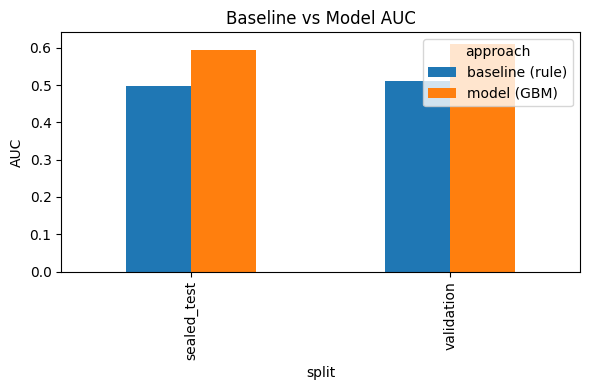

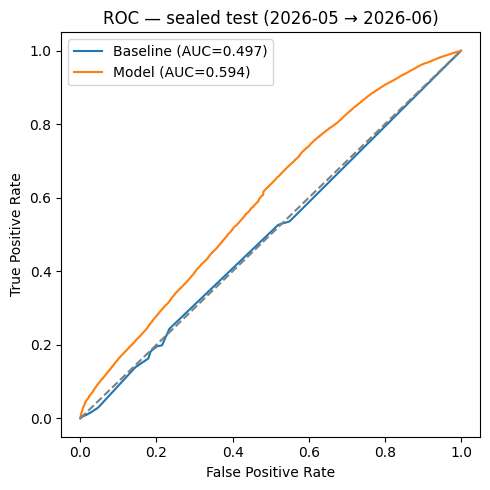

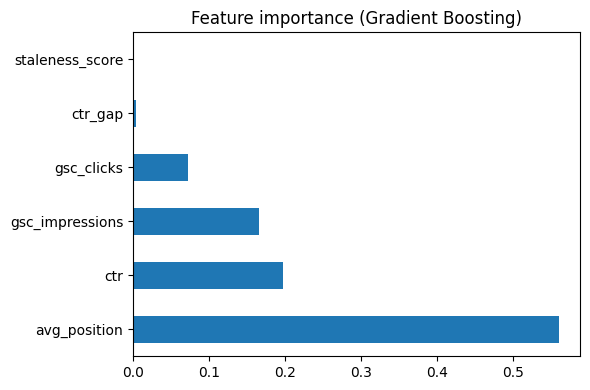

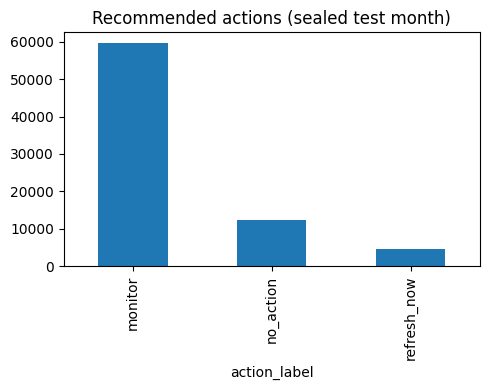

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

os.makedirs("work/outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
results_table.pivot(index="split", columns="approach", values="auc").plot(kind="bar", ax=ax)
ax.set_ylabel("AUC"); ax.set_title("Baseline vs Model AUC")
plt.tight_layout(); plt.savefig("work/outputs/figures/auc_comparison.png", dpi=150); plt.show()

fpr_b, tpr_b, _ = roc_curve(y_test, baseline_test_score)
fpr_m, tpr_m, _ = roc_curve(y_test, model_test_score)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_b, tpr_b, label=f"Baseline (AUC={baseline_test_auc:.3f})")
ax.plot(fpr_m, tpr_m, label=f"Model (AUC={model_test_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — sealed test (2026-05 → 2026-06)"); ax.legend()
plt.tight_layout(); plt.savefig("work/outputs/figures/roc_sealed_test.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
feature_importance.plot(kind="barh", ax=ax)
ax.set_title("Feature importance (Gradient Boosting)")
plt.tight_layout(); plt.savefig("work/outputs/figures/feature_importance.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
recommendations["action_label"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Recommended actions (sealed test month)")
plt.tight_layout(); plt.savefig("work/outputs/figures/action_distribution.png", dpi=150); plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
